## Plot for kernel test

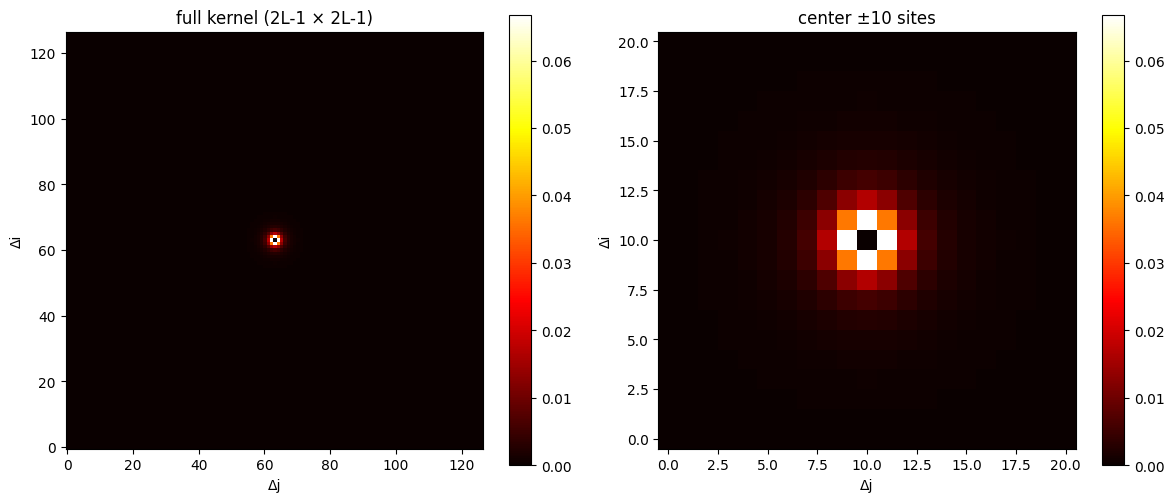

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")  # so imports from src/ work from inside analysis/

from src.kernel import build_kernel

L = 64
r0=1.0
K = build_kernel(L, r0=r0, epsilon_dissipation=0.01)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# full kernel footprint
im0 = axes[0].imshow(K, cmap="hot", origin="lower")
axes[0].set_title("full kernel (2L-1 × 2L-1)")
axes[0].set_xlabel("Δj"); axes[0].set_ylabel("Δi")
plt.colorbar(im0, ax=axes[0])

# zoom into the center (±10 sites) to see the regularization
c = L - 1  # center index
w = 10
im1 = axes[1].imshow(K[c-w:c+w+1, c-w:c+w+1], cmap="hot", origin="lower")
axes[1].set_title(f"center ±{w} sites")
axes[1].set_xlabel("Δj"); axes[1].set_ylabel("Δi")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

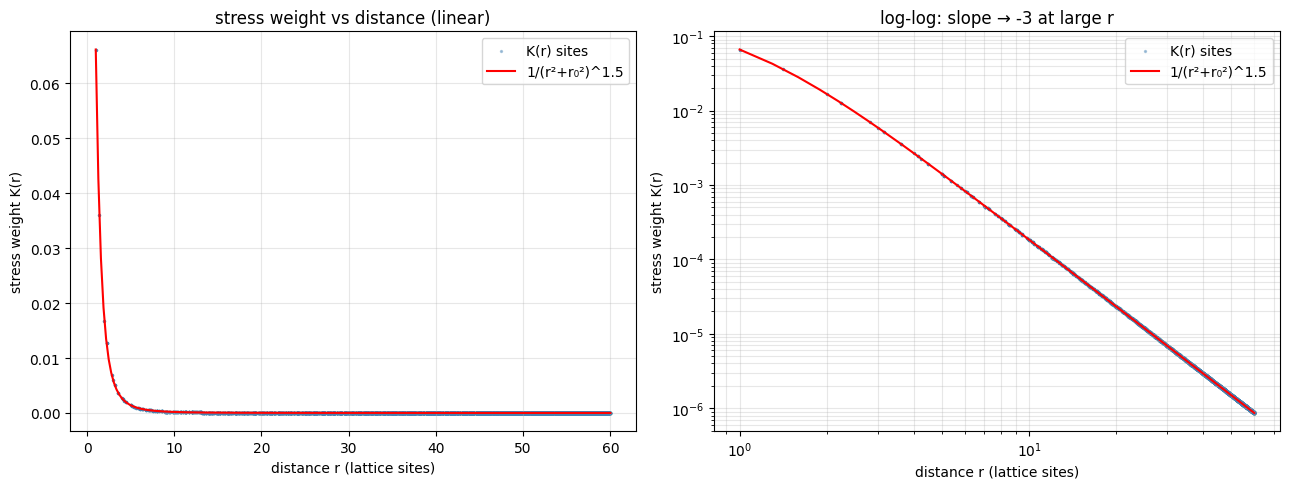

In [2]:
c = L - 1
max_r = 60
rs, ks = [], []

for di in range(-max_r, max_r + 1):
    for dj in range(-max_r, max_r + 1):
        r = np.sqrt(di**2 + dj**2)
        if 0 < r <= max_r:
            rs.append(r)
            ks.append(K[c + di, c + dj])

rs = np.array(rs)
ks = np.array(ks)

# theoretical 1/r^3 line for comparison
r_theory = np.linspace(1, max_r, 200)
k_theory = ks[np.argmin(np.abs(rs - 1))] * (1 + r0**2) ** 1.5 / (r_theory**2 + r0**2) ** 1.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter: every site's actual weight vs its distance
axes[0].scatter(rs, ks, s=2, alpha=0.4, color="steelblue", label="K(r) sites")
axes[0].plot(r_theory, k_theory, "r-", linewidth=1.5, label="1/(r²+r₀²)^1.5")
axes[0].set_xlabel("distance r (lattice sites)")
axes[0].set_ylabel("stress weight K(r)")
axes[0].set_title("stress weight vs distance (linear)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# same on log-log: should be a straight line at large r confirming 1/r^3
axes[1].scatter(rs, ks, s=2, alpha=0.4, color="steelblue", label="K(r) sites")
axes[1].plot(r_theory, k_theory, "r-", linewidth=1.5, label="1/(r²+r₀²)^1.5")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("distance r (lattice sites)")
axes[1].set_ylabel("stress weight K(r)")
axes[1].set_title("log-log: slope → -3 at large r")
axes[1].legend()
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


## Heterogeneity test

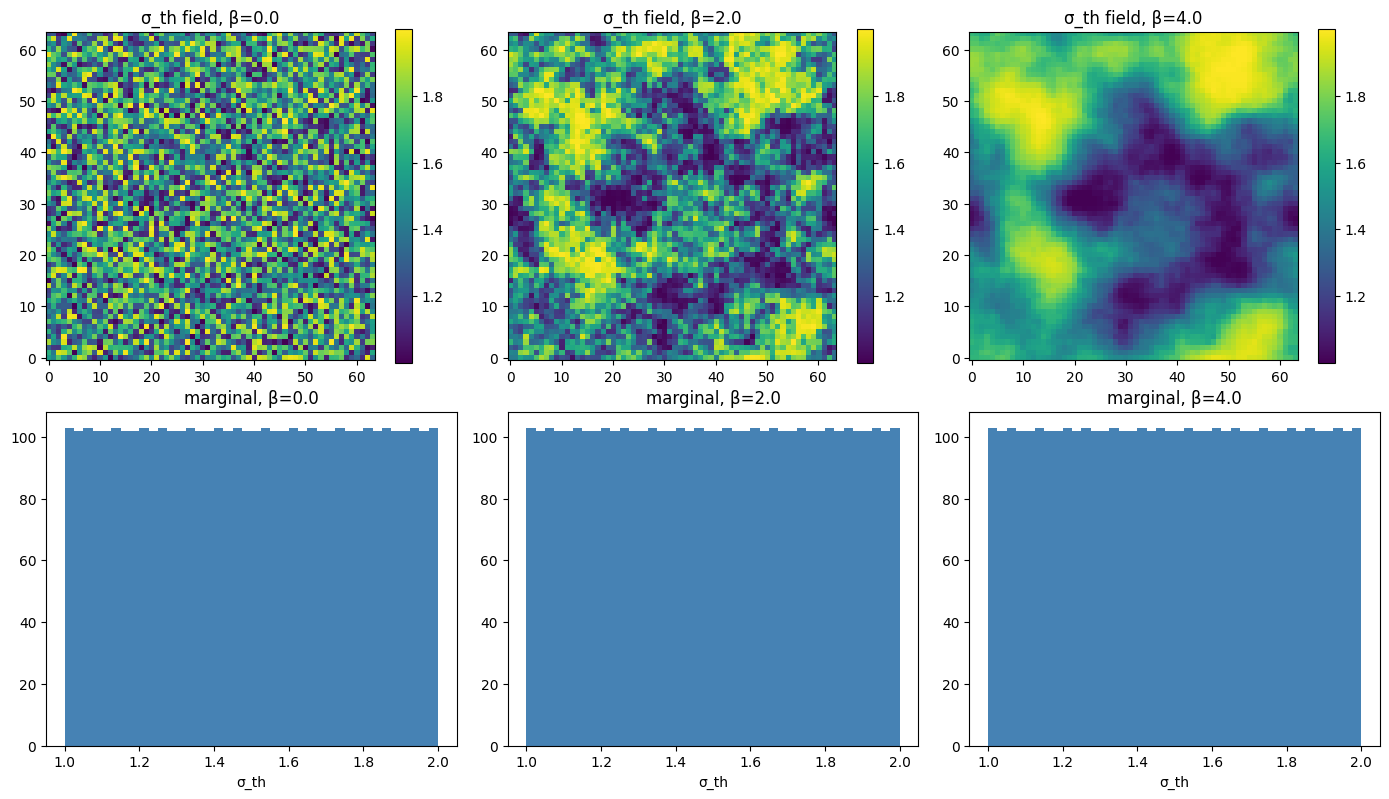

In [3]:
from dataclasses import replace
from src.config import load_config
from src.heterogeneity import threshold_field, residual_field

cfg = load_config("../experiments/params.yaml")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, beta_str in enumerate([0.0, 2.0, 4.0]):
    c = replace(cfg, L=64, beta_str=beta_str)              # frozen config -> make a modified copy
    sth = threshold_field(c, np.random.default_rng(0))

    im = axes[0, col].imshow(sth, cmap="viridis", origin="lower")
    axes[0, col].set_title(f"σ_th field, β={beta_str}")
    plt.colorbar(im, ax=axes[0, col])

    axes[1, col].hist(sth.ravel(), bins=40, color="steelblue")
    axes[1, col].set_title(f"marginal, β={beta_str}")
    axes[1, col].set_xlabel("σ_th")

plt.tight_layout()
plt.show()

# Lattice

initial: FaultLattice(L=128, mean_sigma=0.7433, max_risk=1.0000)
unstable before load: 0
max risk before load: 0.9999820655513608

loaded by Δσ = 0.00
unstable after load: 1
their risk ratio: [1.]


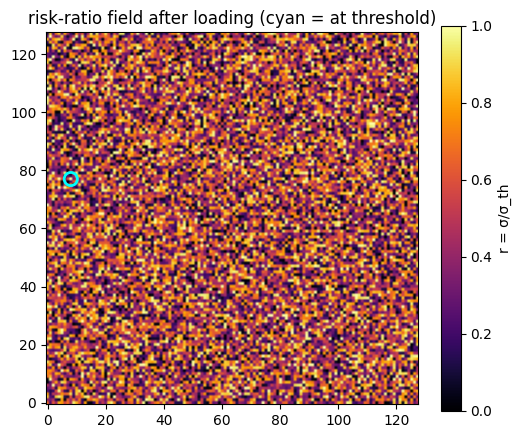

shed stress S at failed site: [1.13607788]
sigma after reset: [0.] (should equal sigma_res = 0.0 )


In [4]:
from src.lattice import FaultLattice

cfg = load_config("../experiments/params.yaml")
lat = FaultLattice(cfg)

print("initial:", lat)
print("unstable before load:", lat.unstable_sites().sum())
print("max risk before load:", lat.risk_ratio().max())

dsig = lat.load_to_failure()
mask = lat.unstable_sites()
print(f"\nloaded by Δσ = {dsig:.2f}")
print("unstable after load:", mask.sum())
print("their risk ratio:", lat.risk_ratio()[mask])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(lat.risk_ratio(), cmap="inferno", origin="lower", vmin=0, vmax=1)
yi, xi = np.where(mask)
ax.scatter(xi, yi, s=90, facecolors="none", edgecolors="cyan", linewidths=2)
ax.set_title("risk-ratio field after loading (cyan = at threshold)")
plt.colorbar(im, ax=ax, label="r = σ/σ_th")
plt.show()

source = lat.fail(mask)
print("shed stress S at failed site:", source[mask])          # = sigma_th - sigma_res
print("sigma after reset:", lat.sigma[mask], "(should equal sigma_res =", cfg.sigma_res, ")")

# redistribution

    def __init__(self, cfg: Config) -> None:
        self.cfg = cfg
        self.L = cfg.L
        self.bc = cfg.boundary_condition

        K = build_kernel(cfg.L, cfg.r0, cfg.epsilon_dissipation, cfg.kernel_kind, cfg.theta0)
        # K is centered: K[L-1, L-1] is zero displacement (di=dj=0).

        if self.bc == "periodic":
            self._pad_shape = (self.L, self.L)
            self._embed = lambda field, shape: field  # no padding needed
            K_padded = _wrap_kernel(K, self._pad_shape)
            self._K_hat = np.fft.fft2(K_padded)
            self._extract = lambda padded: padded
            return

        self._pad_shape = _PAD_SHAPE[self.bc](self.L)
        self._embed = _EMBED_FUNCS[self.bc]
        K_padded = _wrap_kernel(K, self._pad_shape)
        self._K_hat = np.fft.fft2(K_padded)
        self._extract = lambda padded: padded[: self.L, : self.L]



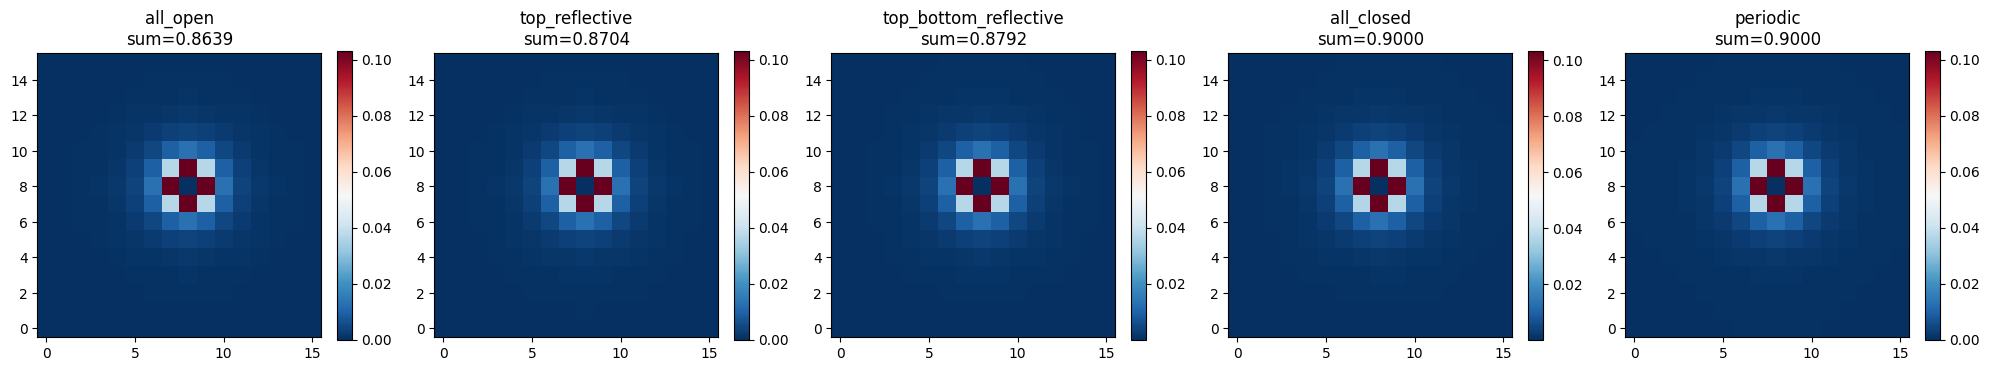

In [5]:
from src.redistributionv2 import Redistributor
from dataclasses import replace
import inspect
print(inspect.getsource(Redistributor.__init__))
L = 16  # small, so the padded arrays and plots are readable
cfg_small = replace(cfg, L=L)

source = np.zeros((L, L))
source[L // 2, L // 2] = 1.0  # single unit source, center

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, bc in zip(axes, ["all_open", "top_reflective", "top_bottom_reflective", "all_closed", "periodic"]):
    rd = Redistributor(replace(cfg_small, boundary_condition=bc))
    delta = rd.redistribute(source)
    im = ax.imshow(delta, cmap="RdBu_r", origin="lower")
    ax.set_title(f"{bc}\nsum={delta.sum():.4f}")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# Avalanche

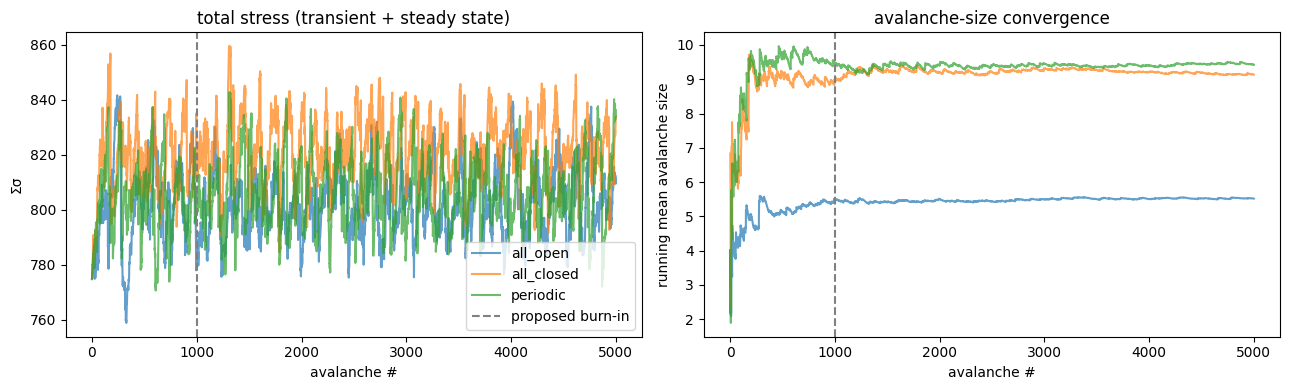

In [6]:
from src.dynamics import run
from dataclasses import replace

L = 32
n_avalanches = 5000
burn_in = 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for bc in ["all_open", "all_closed", "periodic"]:
    c = replace(cfg, L=L, boundary_condition=bc, seed=0)
    lat = FaultLattice(c)
    rd = Redistributor(c)

    sigma_totals = []
    sizes = []
    for rec in run(lat, rd, n_avalanches, burn_in=0):  # no discard yet, to see the transient
        sigma_totals.append(rec.sigma_total)
        sizes.append(rec.size)

    axes[0].plot(sigma_totals, label=bc, alpha=0.7)
    axes[1].plot(np.cumsum(sizes) / (np.arange(len(sizes)) + 1), label=bc, alpha=0.7)

axes[0].axvline(burn_in, color="gray", linestyle="--", label="proposed burn-in")
axes[0].set_xlabel("avalanche #"); axes[0].set_ylabel("Σσ")
axes[0].set_title("total stress (transient + steady state)")
axes[0].legend()

axes[1].axvline(burn_in, color="gray", linestyle="--")
axes[1].set_xlabel("avalanche #"); axes[1].set_ylabel("running mean avalanche size")
axes[1].set_title("avalanche-size convergence")

plt.tight_layout()
plt.show()